In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from typing import *
from itertools import product

In [2]:
df_all = pd.read_csv('test_results.csv', encoding='UTF-8')
print(tabulate(df_all.head(10), headers=df_all.columns))

TYPES = df_all['GraphType'].unique()
DENSITIES = df_all['Density'].unique()

def graph_name_to_pl(g_type:str) -> str:
    if g_type == "Edge":
        return "Lista krawędzi"
    elif g_type == "List":
        return "Lista sąsiedztwa"
    elif g_type == "Matrix":
        return "Macierz sąsiedztwa"
    else:
        raise ValueError(f"Unknown graph type: {g_type}") 

      Rep    Size    Density  GraphType      CreationTime    SizeInBytes    GetWeightTimeMs    SetConnectionTimeMs
--  -----  ------  ---------  -----------  --------------  -------------  -----------------  ---------------------
 0      0     700       0.25  List               0.007175        1965624           0.000314               0.000752
 1      0     800       0.5   Matrix             1.8871          2566424           1.4e-05                7e-06
 2      0     600       0.25  List               0.002203        1444824           0.00055                4.6e-05
 3      0     700       0.5   Matrix             1.32156         1965624           1.3e-05                7e-06
 4      0     500       0.25  Edge               0.000113        1500032           0.12447                0.29547
 5      0     800       0.25  List               0.002147        2566424           0.000687               0.000155
 6      0     700       0.25  Matrix             1.36871         1965624           1.2e-

In [3]:
df_gr = df_all.groupby(['Size', 'Density', 'GraphType']).agg(
    CreationTimeMsAvg = ('CreationTime', 'mean'),
    CreationTimeMsStd = ('CreationTime', 'std'),
    SizeInBytesAvg = ('SizeInBytes', 'mean'),
    SizeInBytesStd = ('SizeInBytes', 'std'),
    GetWeightTimeMs = ('GetWeightTimeMs', 'mean'),
    GetWeightTimeMsStd = ('GetWeightTimeMs', 'std'),
    SetConnectionTimeMs = ('SetConnectionTimeMs', 'mean'),
    SetConnectionTimeMsStd = ('SetConnectionTimeMs', 'std'),
).reset_index()

print(tabulate(df_gr.head(10), headers=df_gr.columns))

      Size    Density  GraphType      CreationTimeMsAvg    CreationTimeMsStd    SizeInBytesAvg    SizeInBytesStd    GetWeightTimeMs    GetWeightTimeMsStd    SetConnectionTimeMs    SetConnectionTimeMsStd
--  ------  ---------  -----------  -------------------  -------------------  ----------------  ----------------  -----------------  --------------------  ---------------------  ------------------------
 0     100       0.25  Edge                 0.00014              2.96985e-05             60032                 0          0.012339            0.0136627              0.014147                  0.0103945
 1     100       0.25  List                 0.001322             0.000402546             40824                 0          8.1e-05             8.56096e-05            6.63333e-05               9.24626e-05
 2     100       0.25  Matrix               0.066546             0.00233911              40824                 0          1.65e-05            7.07107e-07            1.45e-05                 

In [4]:
def prepare_df_per_experiment(df: pd.DataFrame, org_cols: List[str], measurement_name: str):
    df =  df.pivot_table(
        index=['Size', 'Density'], 
        columns='GraphType', 
        values=org_cols
    ).reset_index()
    
    df.columns = ['Size', 'Density', 
                  f'Edge{measurement_name}Avg', f'List{measurement_name}Avg', f'Matrix{measurement_name}Avg', 
                  f'Edge{measurement_name}Std', f'List{measurement_name}Std', f'Matrix{measurement_name}Std']
    df = df[['Size', 'Density',
             f'Edge{measurement_name}Avg', f'Edge{measurement_name}Std',
             f'List{measurement_name}Avg', f'List{measurement_name}Std',
             f'Matrix{measurement_name}Avg', f'Matrix{measurement_name}Std'
             ]]
    print(f"DF: {measurement_name}")
    print(tabulate(df.head(), headers=df.columns))
    return df


df_create = prepare_df_per_experiment(df_gr, ['CreationTimeMsAvg', 'CreationTimeMsStd'], 'Create')
df_memory = prepare_df_per_experiment(df_gr, ['SizeInBytesAvg', 'SizeInBytesStd'], 'Memory')
df_find = prepare_df_per_experiment(df_gr, ['GetWeightTimeMs', 'GetWeightTimeMsStd'], 'Find')
df_add = prepare_df_per_experiment(df_gr, ['SetConnectionTimeMs', 'SetConnectionTimeMsStd'], 'Add')


DF: Create
      Size    Density    EdgeCreateAvg    EdgeCreateStd    ListCreateAvg    ListCreateStd    MatrixCreateAvg    MatrixCreateStd
--  ------  ---------  ---------------  ---------------  ---------------  ---------------  -----------------  -----------------
 0     100       0.25      0.00014          2.96985e-05       0.001322        0.000402546          0.066546          0.00233911
 1     100       0.5       0.000153333      3.98288e-05       0.000676        0.000321026          0.0401735         0.0226932
 2     100       0.75      0.000171         4.3589e-05        0.00091         0.000730183          0.0307465         0.0143719
 3     200       0.25      0.0001615        2.19203e-05       0.00252667      0.00178995           0.078825          0.00453538
 4     200       0.5       0.000214667      0.000105249       0.00123233      0.00092636           0.0838575         0.0107049
DF: Memory
      Size    Density    EdgeMemoryAvg    EdgeMemoryStd    ListMemoryAvg    ListMemor

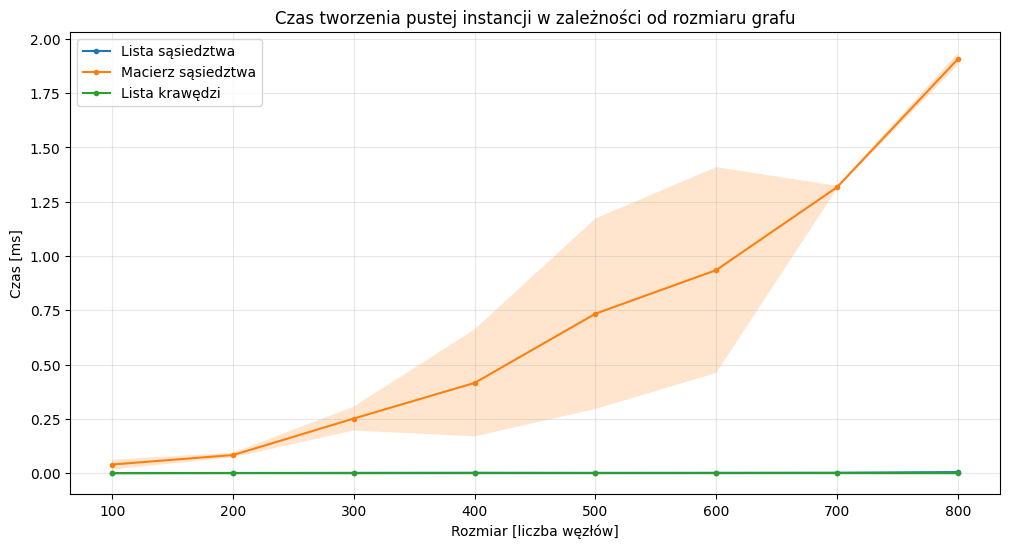

In [5]:
#! CREATION TIME

def creation_plot(df, measurement_name: str, graph_types: List[str], title: str, y_axis_name:str):
    fig, ax = plt.subplots(figsize=(12,6))
    
    df = df[df['Density']==0.5]
    
    for g_type in graph_types:
        label = f'{graph_name_to_pl(g_type)}'
        avg_col = f'{g_type}{measurement_name}Avg'
        std_col = f'{g_type}{measurement_name}Std'
        x = df["Size"]
        
        ax.plot(x, df[avg_col], marker='o', label=label, markersize=3)
        ax.fill_between(x, df[avg_col] - df[std_col], df[avg_col] + df[std_col], alpha=0.2)
    
    ax.set_title(title)
    ax.set_xlabel("Rozmiar [liczba węzłów]")
    ax.set_ylabel(y_axis_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()
    
creation_plot(df_create, 'Create', graph_types=TYPES, 
            title="Czas tworzenia pustej instancji w zależności od rozmiaru grafu",
            y_axis_name="Czas [ms]")


In [6]:
def create_subplots_with_dens(df, measurement_name: str, title: str, y_axis_name:str):
    fig, ax = plt.subplots(2, 2, figsize=(12,8))
    
    def single(graph_types, ax_tmp):
        for g_type, dens in product(graph_types, DENSITIES):
            sub_df = df[df["Density"] == dens]
            label = f'{graph_name_to_pl(g_type)}, gęst.={dens}'
            avg_col = f'{g_type}{measurement_name}Avg'
            std_col = f'{g_type}{measurement_name}Std'
            x = sub_df["Size"]
            
            ax_tmp.plot(x, sub_df[avg_col], marker='o', label=label, markersize=3)
            ax_tmp.fill_between(x, sub_df[avg_col] - sub_df[std_col], sub_df[avg_col] + sub_df[std_col], alpha=0.2)
        
        ax_tmp.set_xlabel("Rozmiar [liczba węzłów]")
        ax_tmp.set_ylabel(y_axis_name)
        ax_tmp.legend()
        ax_tmp.grid(True, alpha=0.3)

    single(TYPES, ax[0, 0])
    single(['Edge'], ax[0, 1])
    single(['List'], ax[1, 0])
    single(['Matrix'], ax[1, 1])
    
    fig.suptitle(title, fontsize=16)
   
    plt.tight_layout()
    plt.show()

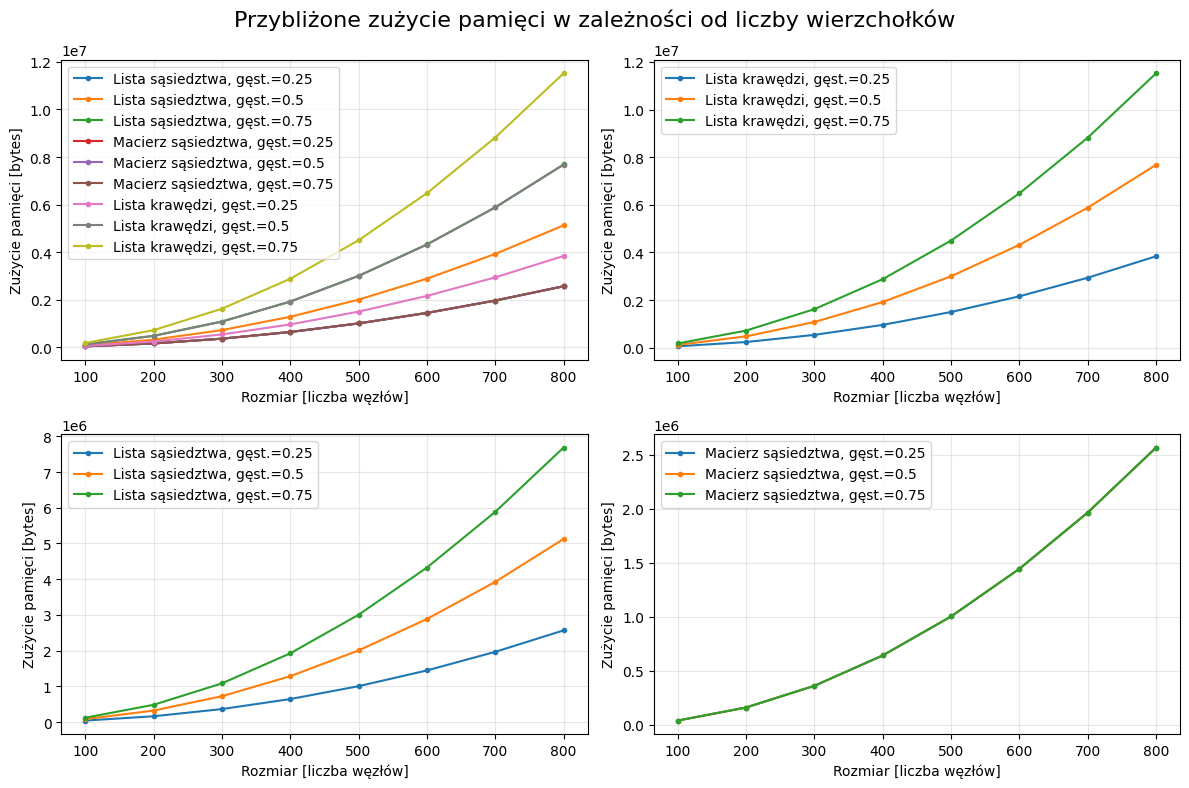

In [7]:
#! MEMORY USED
create_subplots_with_dens(df_memory, 'Memory', 
            title="Przybliżone zużycie pamięci w zależności od liczby wierzchołków",
            y_axis_name="Zużycie pamięci [bytes]")


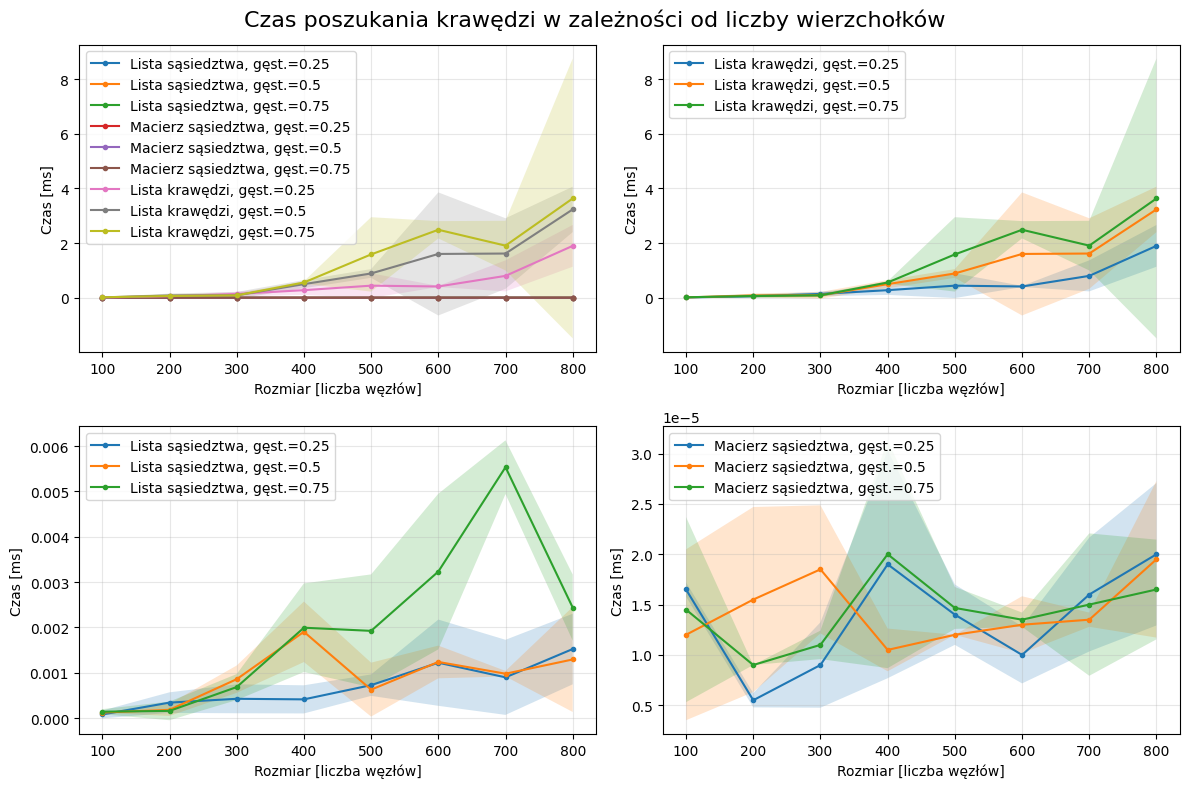

In [8]:
#! FIND TIME
create_subplots_with_dens(df_find, 'Find', 
            title="Czas poszukania krawędzi w zależności od liczby wierzchołków",
            y_axis_name="Czas [ms]")


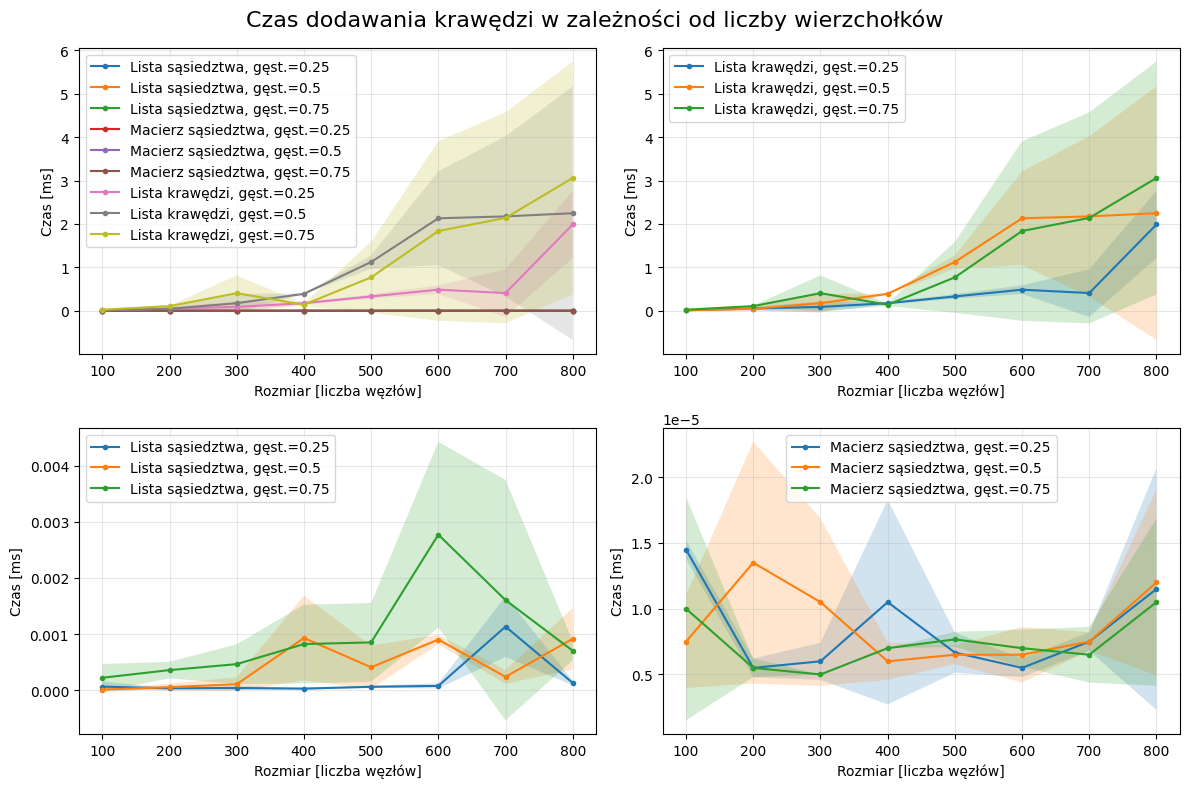

In [9]:
#! ADD EDGE TIME
create_subplots_with_dens(df_add, 'Add', 
            title="Czas dodawania krawędzi w zależności od liczby wierzchołków",
            y_axis_name="Czas [ms]")